In [25]:
import math


ARM_LENGTH = 5.0
ARM_MASS = 5.0

STARTING_ARM_THETA = math.radians(45) # in rad

GRAVITY = -9.8
FRICTION = 1.5

DT = 0.001


KP = 0.3
KD = 0.3
KI = 0.1


# so arm theta -> wheel torque -> arm atheta -> arm vtheta -> arm theta
# PID would control wheel torque - the error would be desired arm theta - measured arm theta


class System:

    def __init__(self, arm_length, arm_mass, arm_theta):

        self.arm_length = arm_length
        self.arm_mass = arm_mass
        self.arm_theta = arm_theta
        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)
        
        self.arm_atheta = 3/(2 * self.arm_length) * GRAVITY * math.sin(self.arm_theta)
        self.arm_vtheta = 0

        self.arm_thetas = []
        self.arm_vthetas = []
        self.arm_athetas = []


    def solve_for_theta(self):
        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)

        self.arm_atheta = (self.arm_torque + FRICTION * (-1 if self.arm_vtheta > 0 else 1)) / self.arm_moment
        self.arm_vtheta = self.arm_vtheta + self.arm_atheta * DT
        self.arm_theta = self.arm_theta + self.arm_vtheta * DT

        self.arm_athetas.append(self.arm_atheta)
        self.arm_vthetas.append(self.arm_vtheta)
        self.arm_thetas.append(self.arm_theta)


    def loop(self):
        for i in range(100000):
            self.solve_for_theta()





In [26]:
pendulum = System(ARM_LENGTH, ARM_MASS, STARTING_ARM_THETA)
pendulum.loop()

In [27]:
pendulum.arm_thetas[-1]

0.00019462041580265007

saved -> pendulum.gif  (400 frames @ 30 fps = 13.3s of playback, covering 100s of sim time)


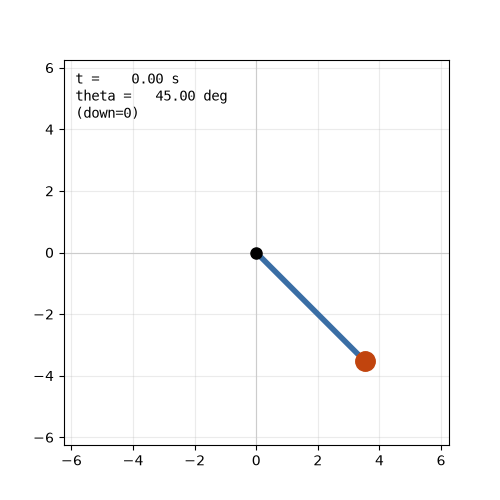

'pendulum.gif'

In [28]:
from viz import animate_pendulum

# inline HTML5 player in Jupyter:
animate_pendulum(pendulum.arm_thetas, arm_length=ARM_LENGTH,
                 units='rad', zero_ref='down', dt=DT)

In [ ]:



class ReactionWheelSystem(System):

    def __init__(self, arm_length, arm_mass, arm_theta, wheel_mass, wheel_radius):
        
        super().__init__(arm_length, arm_mass, arm_theta)

        self.wheel_radius = wheel_radius
        self.wheel_mass = wheel_mass
        
        self.wheel_moment = self.wheel_mass * self.wheel_radius**2 # moment for a hoop (mass is all along radius r)
        self.wheel_torque = 0 # this is the motor input

        self.wheel_atheta = self.wheel_torque / self.wheel_moment
        self.wheel_vtheta = 0
        self.wheel_theta = 0


        self.wheel_athetas = []
        self.wheel_vthetass = []
        self.wheel_thetas = []

        self.errors = []

    

    def wheel_torque_PID_response(self):
        desired_arm_theta = MATH.PI
        measured_arm_theta = self.arm_theta
        
        error = desired_arm_theta - measured_arm_theta

        self.errors.append(error)
        
        i_term = KI * sum(self.errors)
        PID = KP * error + KD * -1* self.arm_vtheta

        return PID


    

    def solve_for_theta(self):

        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2) + (self.wheel_mass * self.arm_length**2)
        self.arm_torque = (self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)) + (self.wheel_mass * self.arm_length * GRAVITY + math.sin(self.arm_theta))

        self.wheel_torque = wheel_torque_PID_response # PID system should create a signal for wheel torque here

        self.wheel_atheta = self.wheel_torque / self.wheel_moment
        self.wheel_vtheta = self.wheel_vtheta + self.wheel_atheta * DT
        self.wheel_theta = self.wheel_theta + self.wheel_vtheta * DT

        self.arm_atheta = (self.arm_torque + (-1 * self.wheel_torque) + FRICTION * (-1 if self.arm_vtheta > 0 else 1)) / self.arm_moment
        self.arm_vtheta = self.arm_vtheta + self.arm_atheta * DT
        self.arm_theta = self.arm_theta + self.arm_vtheta * DT

        self.arm_athetas.append(self.arm_atheta)
        self.arm_vthetas.append(self.arm_vtheta)
        self.arm_thetas.append(self.arm_theta)
        

    def loop(self):
        for i in range(100000):
            self.solve_for_theta()

